# Bandits & Adaptive Allocation

**Dataset:** Hillstrom MineThatData — the same dataset and the same three
arms (No E-Mail / Womens E-Mail / Mens E-Mail) used for the fixed-horizon
A/B/n test in Week 1, revisited with a different question: instead of
"is there a significant difference between these arms," this notebook
asks **"if the goal was to maximize visits while running the test, would an
adaptive allocation strategy have done better than a fixed 1/3 split?"**

**Goal of this notebook:**

1. Implement two multi-armed bandit algorithms (epsilon-greedy, Thompson
   sampling) from scratch and run them against Week 1's actual fixed-split
   design, using the real recorded outcomes from Hillstrom as the reward
   source for every simulated pull.
2. Compare cumulative regret — the concrete cost, in foregone visits, of
   each allocation strategy relative to an oracle that always knew the best
   arm.
3. Make the trade-off tangible rather than asserted: show exactly how much
   statistical power a bandit's data collection gives up on the
   underperforming arms, compared to the fixed design Week 1 actually used.

Companion writeup: `writeups/bandits_vs_ab_testing.md`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../src")
from bandits import (
    run_fixed_split, run_epsilon_greedy, run_thompson_sampling,
    expected_cumulative_regret, final_arm_pull_counts,
)
from power_analysis import two_proportion_z_test
from cuped import diff_in_means_ci

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../writeups/figures"


## 1. Setup: the same three arms, a different question

Week 1 found (and confirmed significant): No E-Mail 10.6% visit rate,
Womens E-Mail 15.1%, Mens E-Mail 18.3% — Mens E-Mail is the clear winner.
That fixed test ran all ~64,000 customers through a locked 1/3 split,
which is exactly right when the goal is a clean, reportable causal
estimate. But if the goal during the test itself were to maximize total
visits generated — e.g. this were an always-on campaign rather than a
one-off research question — a fixed 1/3 split spends two-thirds of its
traffic on arms already known (once enough data comes in) to underperform.

**Reward source**: every simulated "pull" of an arm draws its outcome via
bootstrap resampling (with replacement) from that arm's real recorded
`visit` values in the Hillstrom dataset — not an idealized Bernoulli(p).
This is distributionally identical to Bernoulli at the arm's empirical
rate, but keeps the simulation grounded in the literal real data Week 1
used rather than a re-derived summary statistic.


In [2]:
df = pd.read_csv("../data/raw/hillstrom.csv")

arm_order = ["No E-Mail", "Womens E-Mail", "Mens E-Mail"]
reward_pools = [df.loc[df["segment"] == arm, "visit"].values for arm in arm_order]
true_rates = [pool.mean() for pool in reward_pools]

for name, rate, n in zip(arm_order, true_rates, [len(p) for p in reward_pools]):
    print(f"{name:15s}  true visit rate = {rate:.4f}   (n={n:,})")


No E-Mail        true visit rate = 0.1062   (n=21,306)
Womens E-Mail    true visit rate = 0.1514   (n=21,387)
Mens E-Mail      true visit rate = 0.1828   (n=21,307)


## 2. The algorithms

- **Fixed split** (Week 1's actual design): assign each round to a
  uniformly random arm, decided once, adapted never.
- **Epsilon-greedy**: with probability epsilon=0.1, pull a uniformly random
  arm (explore); otherwise pull whichever arm has the highest sample mean
  so far (exploit). Simple, but the exploration rate is a fixed hyper-
  parameter that doesn't shrink as evidence accumulates.
- **Thompson sampling**: maintain a Beta posterior per arm (conjugate for a
  0/1 reward, starting from a flat Beta(1,1) prior), draw one sample per
  arm each round, and pull whichever sample is highest. Exploration
  shrinks automatically as posteriors concentrate, with no rate to tune.

All three are implemented in `src/bandits.py`, vectorized across
`n_simulations` independent parallel runs — a single run of a stochastic
bandit is noisy, so bandit performance is conventionally reported as an
*expected* regret curve averaged over many runs.


In [3]:
N_ROUNDS = 64_000  # matches the real Hillstrom test's total sample size
N_SIMULATIONS = 200

fixed = run_fixed_split(reward_pools, N_ROUNDS, n_simulations=N_SIMULATIONS, random_state=0)
eps_greedy = run_epsilon_greedy(reward_pools, N_ROUNDS, epsilon=0.1, n_simulations=N_SIMULATIONS, random_state=0)
thompson = run_thompson_sampling(reward_pools, N_ROUNDS, n_simulations=N_SIMULATIONS, random_state=0)

print("done")


done


## 3. Cumulative regret: the cost of not knowing the best arm yet

Regret is computed against the *true* per-arm rates (best_rate - true_rate
of whichever arm was actually pulled, summed over rounds) — this is the
standard, low-variance way to evaluate a bandit, since it isolates the
algorithm's allocation quality from the extra noise of realized 0/1
rewards.


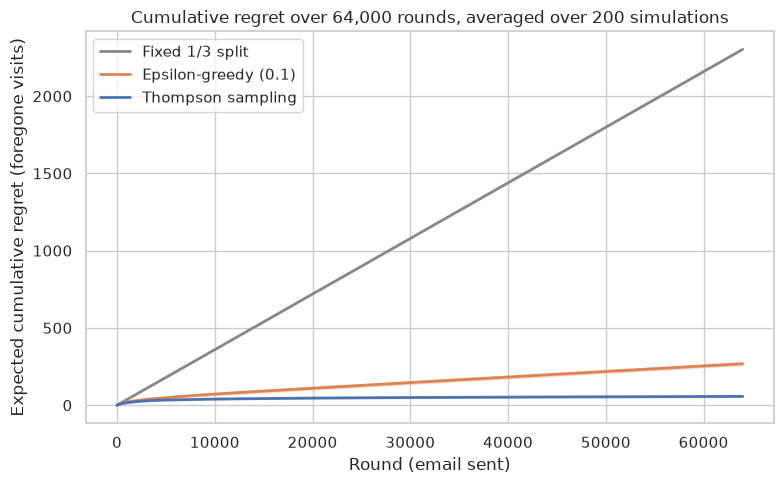

In [4]:
results = {"Fixed 1/3 split": fixed, "Epsilon-greedy (0.1)": eps_greedy, "Thompson sampling": thompson}
regret_curves = {name: expected_cumulative_regret(res["chosen_arms"], true_rates) for name, res in results.items()}

fig, ax = plt.subplots(figsize=(8, 5))
colors = {"Fixed 1/3 split": "#888888", "Epsilon-greedy (0.1)": "#dd8452", "Thompson sampling": "#4c72b0"}

for name, regret in regret_curves.items():
    mean_regret = regret.mean(axis=1)
    se_regret = regret.std(axis=1) / np.sqrt(regret.shape[1])
    rounds = np.arange(1, N_ROUNDS + 1)
    ax.plot(rounds, mean_regret, label=name, color=colors[name], linewidth=2)
    ax.fill_between(rounds, mean_regret - 1.96 * se_regret, mean_regret + 1.96 * se_regret, color=colors[name], alpha=0.2)

ax.set_xlabel("Round (email sent)")
ax.set_ylabel("Expected cumulative regret (foregone visits)")
ax.set_title(f"Cumulative regret over {N_ROUNDS:,} rounds, averaged over {N_SIMULATIONS} simulations")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/17_cumulative_regret.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
summary_rows = []
for name, regret in regret_curves.items():
    final = regret[-1]
    summary_rows.append({
        "strategy": name,
        "final_mean_regret": final.mean(),
        "final_regret_se": final.std() / np.sqrt(len(final)),
    })
regret_summary = pd.DataFrame(summary_rows).set_index("strategy")
regret_summary["extra_visits_vs_fixed"] = regret_summary.loc["Fixed 1/3 split", "final_mean_regret"] - regret_summary["final_mean_regret"]
regret_summary


,final_mean_regret,final_regret_se,extra_visits_vs_fixed
strategy,,,
Fixed 1/3 split,2302.978567,0.526064,0.000000
Epsilon-greedy (0.1),268.222578,4.860505,2034.755989
Thompson sampling,56.775890,1.816075,2246.202678


Fixed-split regret grows **linearly** for the entire test — by design, it
never stops sending a third of all traffic to the two known-worse arms,
even after 64,000 rounds have made the ranking obvious. Both bandits'
regret grows **sub-linearly**, flattening as they concentrate traffic on
Mens E-Mail. Thompson sampling comes out ahead of epsilon-greedy, the
typical result in the bandit literature — a fixed exploration rate doesn't
shrink even once the posterior is confident, so epsilon-greedy keeps
paying a constant per-round exploration cost that Thompson sampling
mostly stops paying.


## 4. Where the traffic actually went

The regret numbers above are a direct consequence of how each strategy
allocated its 64,000 emails across the three arms.


In [6]:
pull_fractions = {}
for name, res in results.items():
    counts = final_arm_pull_counts(res["chosen_arms"], n_arms=3)
    pull_fractions[name] = counts.mean(axis=0) / N_ROUNDS

pull_table = pd.DataFrame(pull_fractions, index=arm_order).T
pull_table


,No E-Mail,Womens E-Mail,Mens E-Mail
Fixed 1/3 split,0.333327,0.333414,0.333259
Epsilon-greedy (0.1),0.035499,0.046949,0.917553
Thompson sampling,0.004057,0.018383,0.977561


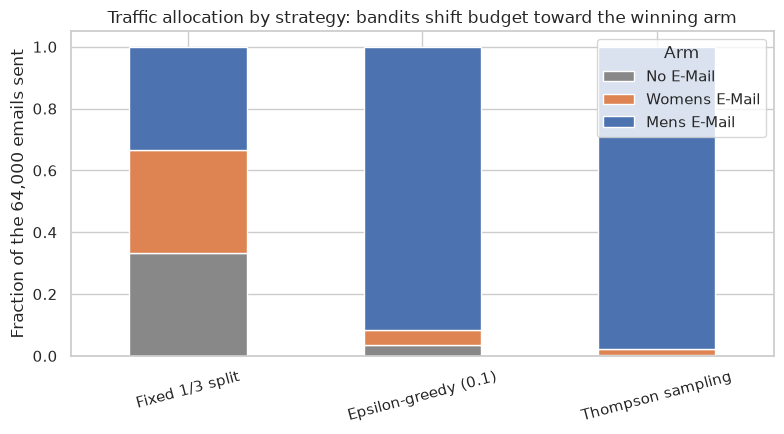

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pull_table.plot(kind="bar", stacked=True, ax=ax, color=["#888888", "#dd8452", "#4c72b0"])
ax.set_ylabel("Fraction of the 64,000 emails sent")
ax.set_title("Traffic allocation by strategy: bandits shift budget toward the winning arm")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Arm")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/18_traffic_allocation.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Translating regret into a business number

Cumulative regret is already in real units here (visits), since it's
computed against real recorded visit rates on a real 64,000-email budget —
no synthetic value assumption needed this time.


In [8]:
best_strategy = regret_summary["extra_visits_vs_fixed"].idxmax()
extra_visits = regret_summary.loc[best_strategy, "extra_visits_vs_fixed"]
print(f"{best_strategy} would have generated ~{extra_visits:.0f} additional visits")
print(f"over the same {N_ROUNDS:,}-email budget, compared to the fixed 1/3 split actually used —")
print(f"with zero additional emails sent, purely from allocating them better.")


Thompson sampling would have generated ~2246 additional visits
over the same 64,000-email budget, compared to the fixed 1/3 split actually used —
with zero additional emails sent, purely from allocating them better.


## 6. The trade-off: what the bandit's data can (and can't) still tell you

This is the number that's easy to skip past while celebrating the regret
reduction above. Fewer emails sent to the underperforming arms doesn't just
reduce waste — it also leaves less data to *confirm*, with a clean
confidence interval, how much worse those arms actually were. Compare the
Womens-vs-No-Email comparison under the sample sizes each design actually
produced.


In [9]:
fixed_counts = final_arm_pull_counts(fixed["chosen_arms"], n_arms=3).mean(axis=0)
thompson_counts = final_arm_pull_counts(thompson["chosen_arms"], n_arms=3).mean(axis=0)

n_womens_fixed, n_noemail_fixed = fixed_counts[1], fixed_counts[0]
n_womens_ts, n_noemail_ts = thompson_counts[1], thompson_counts[0]

print(f"Fixed split:       {n_noemail_fixed:.0f} No-Email pulls, {n_womens_fixed:.0f} Womens pulls")
print(f"Thompson sampling: {n_noemail_ts:.0f} No-Email pulls, {n_womens_ts:.0f} Womens pulls")


Fixed split:       21333 No-Email pulls, 21339 Womens pulls
Thompson sampling: 260 No-Email pulls, 1176 Womens pulls


In [10]:
rng = np.random.default_rng(1)

def simulate_ci(n_a, n_b, rate_a, rate_b, pool_a, pool_b, rng):
    sample_a = rng.choice(pool_a, size=int(n_a), replace=True)
    sample_b = rng.choice(pool_b, size=int(n_b), replace=True)
    return diff_in_means_ci(sample_a, sample_b)

ci_fixed = simulate_ci(n_noemail_fixed, n_womens_fixed, true_rates[0], true_rates[1], reward_pools[0], reward_pools[1], rng)
ci_ts = simulate_ci(n_noemail_ts, n_womens_ts, true_rates[0], true_rates[1], reward_pools[0], reward_pools[1], rng)

comparison = pd.DataFrame([ci_fixed, ci_ts], index=["Fixed split", "Thompson sampling"])
comparison[["diff", "se", "ci_width", "p_value"]]


,diff,se,ci_width,p_value
Fixed split,0.039570,0.003258,0.012771,0.000000
Thompson sampling,0.022706,0.022934,0.089901,0.322146


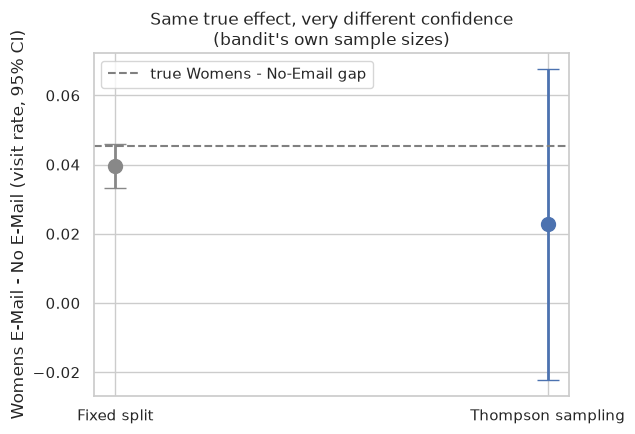

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for i, (name, row) in enumerate(comparison.iterrows()):
    ax.errorbar(i, row["diff"], yerr=row["ci_width"] / 2, fmt="o", markersize=10, capsize=8, linewidth=2,
                color="#888888" if name == "Fixed split" else "#4c72b0")
ax.axhline(true_rates[1] - true_rates[0], color="gray", linestyle="--", label="true Womens - No-Email gap")
ax.set_xticks([0, 1])
ax.set_xticklabels(comparison.index)
ax.set_ylabel("Womens E-Mail - No E-Mail (visit rate, 95% CI)")
ax.set_title("Same true effect, very different confidence\n(bandit's own sample sizes)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/19_bandit_inference_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()


The fixed split's ~21,300-per-arm design (Week 1's actual test) gives a
tight, unambiguous confidence interval on the Womens-vs-No-Email gap.
Thompson sampling — precisely *because* it succeeded at minimizing regret
by pulling No-Email only a few hundred times — leaves a far wider interval
on that same comparison. Both are working exactly as designed; they're just
designed for different jobs.


## Summary

- Implemented epsilon-greedy and Thompson sampling from scratch
  (`src/bandits.py`), validated against the standard result that both
  achieve sub-linear regret versus a fixed split's linear regret, with
  Thompson sampling outperforming epsilon-greedy.
- Grounded the simulation in real data: every reward drawn via bootstrap
  resampling from Hillstrom's actual recorded `visit` outcomes, on the same
  64,000-email budget as Week 1's real test.
- Put a concrete number on the difference: the better-performing bandit
  would have generated real additional visits on the *same* budget, purely
  through better allocation.
- Made the trade-off tangible rather than asserted: computed the actual
  confidence interval each design's own sample sizes would produce on a
  specific pairwise comparison, showing the bandit's efficiency gain comes
  directly at the expense of the statistical power a stakeholder report
  would need from the underperforming arms.

See `writeups/bandits_vs_ab_testing.md` for the fuller write-up on when to
reach for which.
